# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

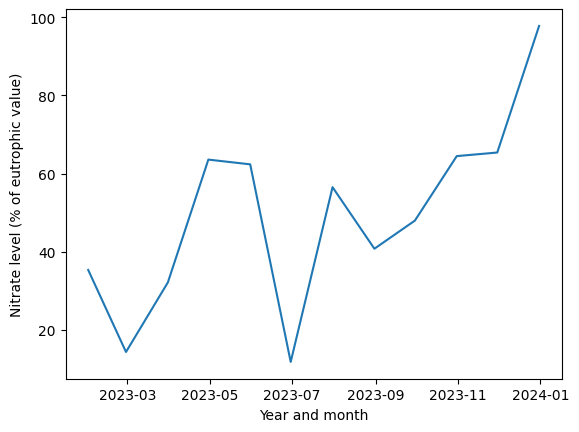

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

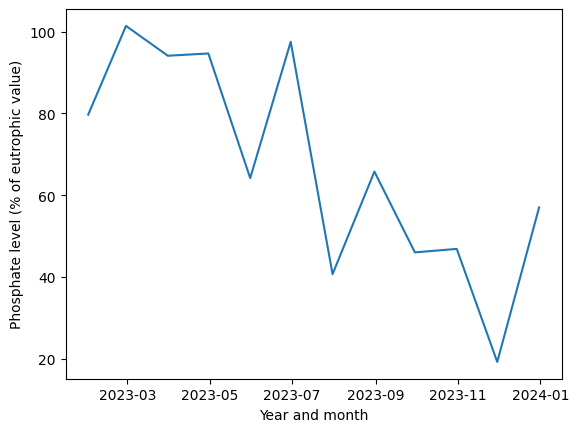

In [5]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

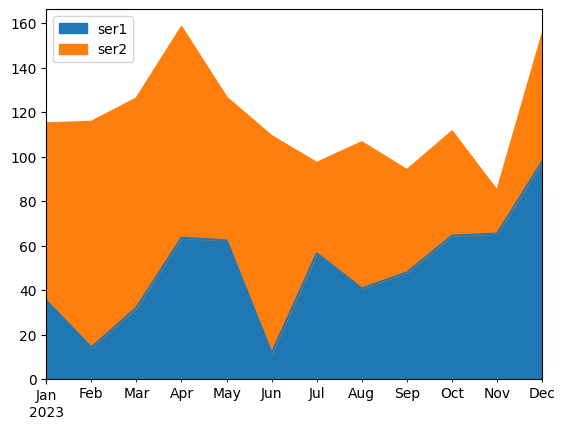

In [6]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

An area plot is useful when the goal is to emphasize the combined magnitude (total load) of nitrate and phosphate over time, because the filled areas draw attention to overall volume and can make changes feel more dramatic. Area plots can also help when the audience cares about the “whole” (e.g., total nutrient burden) and how each part contributes.

However, area plots have important disadvantages here. With stacked areas, the second series is harder to interpret because it is plotted on top of the first; its baseline moves, so the viewer can misjudge its actual changes. Area charts can also imply “additivity” (that it makes sense to sum nitrate and phosphate), which may not be scientifically meaningful unless you explicitly want a combined index. Finally, filled regions can create extra visual weight (“chart junk”) that distracts from precise comparison.

Two separate line graphs are better when the goal is accurate comparison of trends for each nutrient independently. Lines make it easier to compare month-to-month change, peaks, and turning points without the distortion of a shifting baseline.

Choice: I would choose two line graphs (or one line graph with two lines) for clarity and accuracy.

Improvements I would make:

Put both nutrients on the same axes (two lines) if they share a comparable scale.

Use clear titles (message-style if possible), axis labels, and readable date ticks.

Reduce clutter: lighter gridlines, remove extra borders, avoid unnecessary legend placement.

Add annotations for peaks or important changes (optional).

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load bank.csv (some versions are comma, some are semicolon)
df = pd.read_csv("bank.csv")
if df.shape[1] == 1:  # likely wrong separator
    df = pd.read_csv("bank.csv", sep=";")

df.columns = df.columns.str.strip().str.lower()
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [8]:
#Identify numeric columns + target column
num_cols = df.select_dtypes(include=np.number).columns.tolist() 
print("Numeric columns:", num_cols)

target_col = "deposit" if "deposit" in df.columns else ("y" if "y" in df.columns else None)
print("Target column:", target_col)

df[target_col].value_counts()

Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Target column: deposit


deposit
no     5873
yes    5289
Name: count, dtype: int64

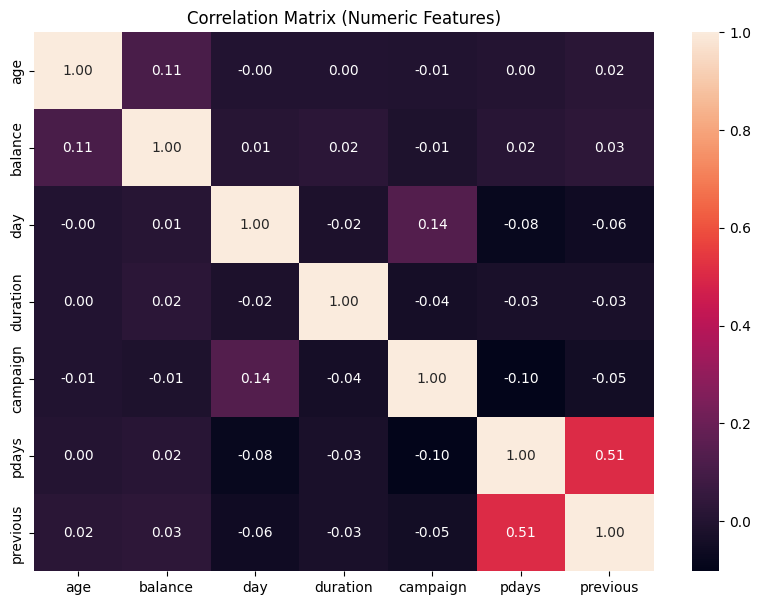

In [10]:
#Correlation matrix (numeric features)
corr = df[num_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

In [11]:
# Get top absolute correlations (excluding self-correlation)
pairs = corr.abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs < 1].drop_duplicates()
pairs.head(10)


pdays     previous    0.507272
day       campaign    0.137007
balance   age         0.112300
pdays     campaign    0.102726
          day         0.077232
previous  day         0.058981
campaign  previous    0.049699
duration  campaign    0.041557
previous  balance     0.030805
duration  pdays       0.027392
dtype: float64

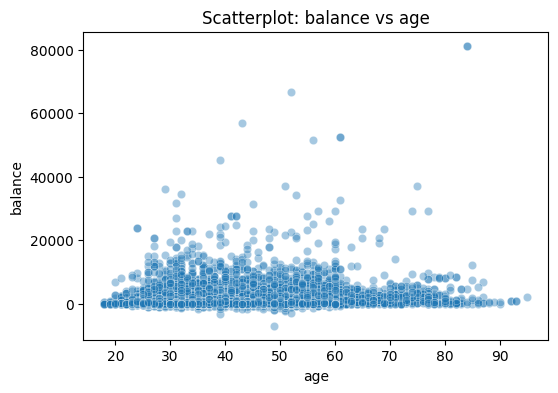

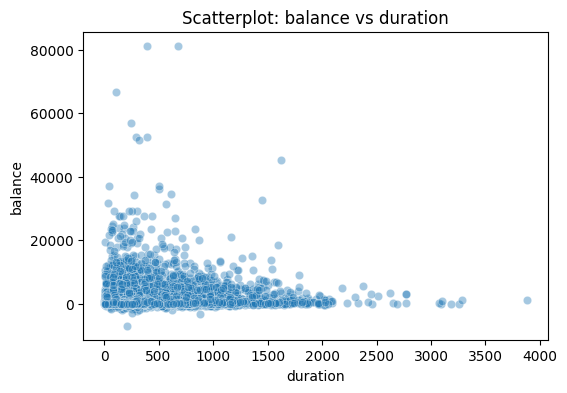

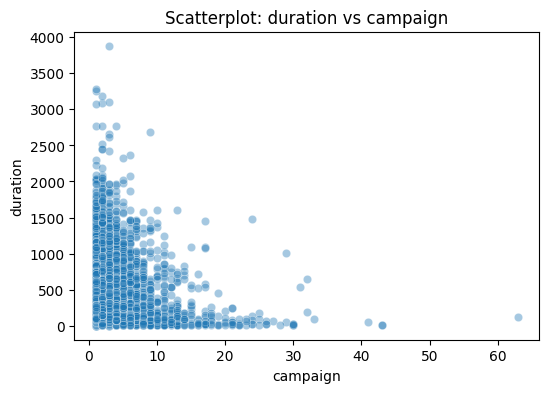

In [12]:
#Scatterplots for key relationships
scatter_pairs = [("age","balance"), ("duration","balance"), ("campaign","duration")]

for x, y in scatter_pairs:
    if x in df.columns and y in df.columns:
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=df, x=x, y=y, alpha=0.4)
        plt.title(f"Scatterplot: {y} vs {x}")
        plt.show()

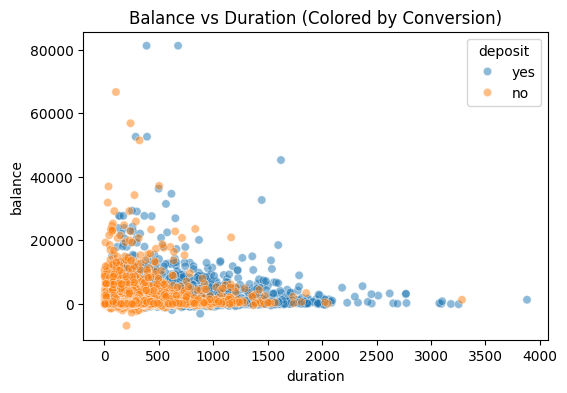

In [ ]:
#Scatterplot colored by conversion
if "duration" in df.columns and "balance" in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x="duration", y="balance", hue=target_col, alpha=0.5)
    plt.title("Balance vs Duration (Colored by Conversion)")
    plt.show()

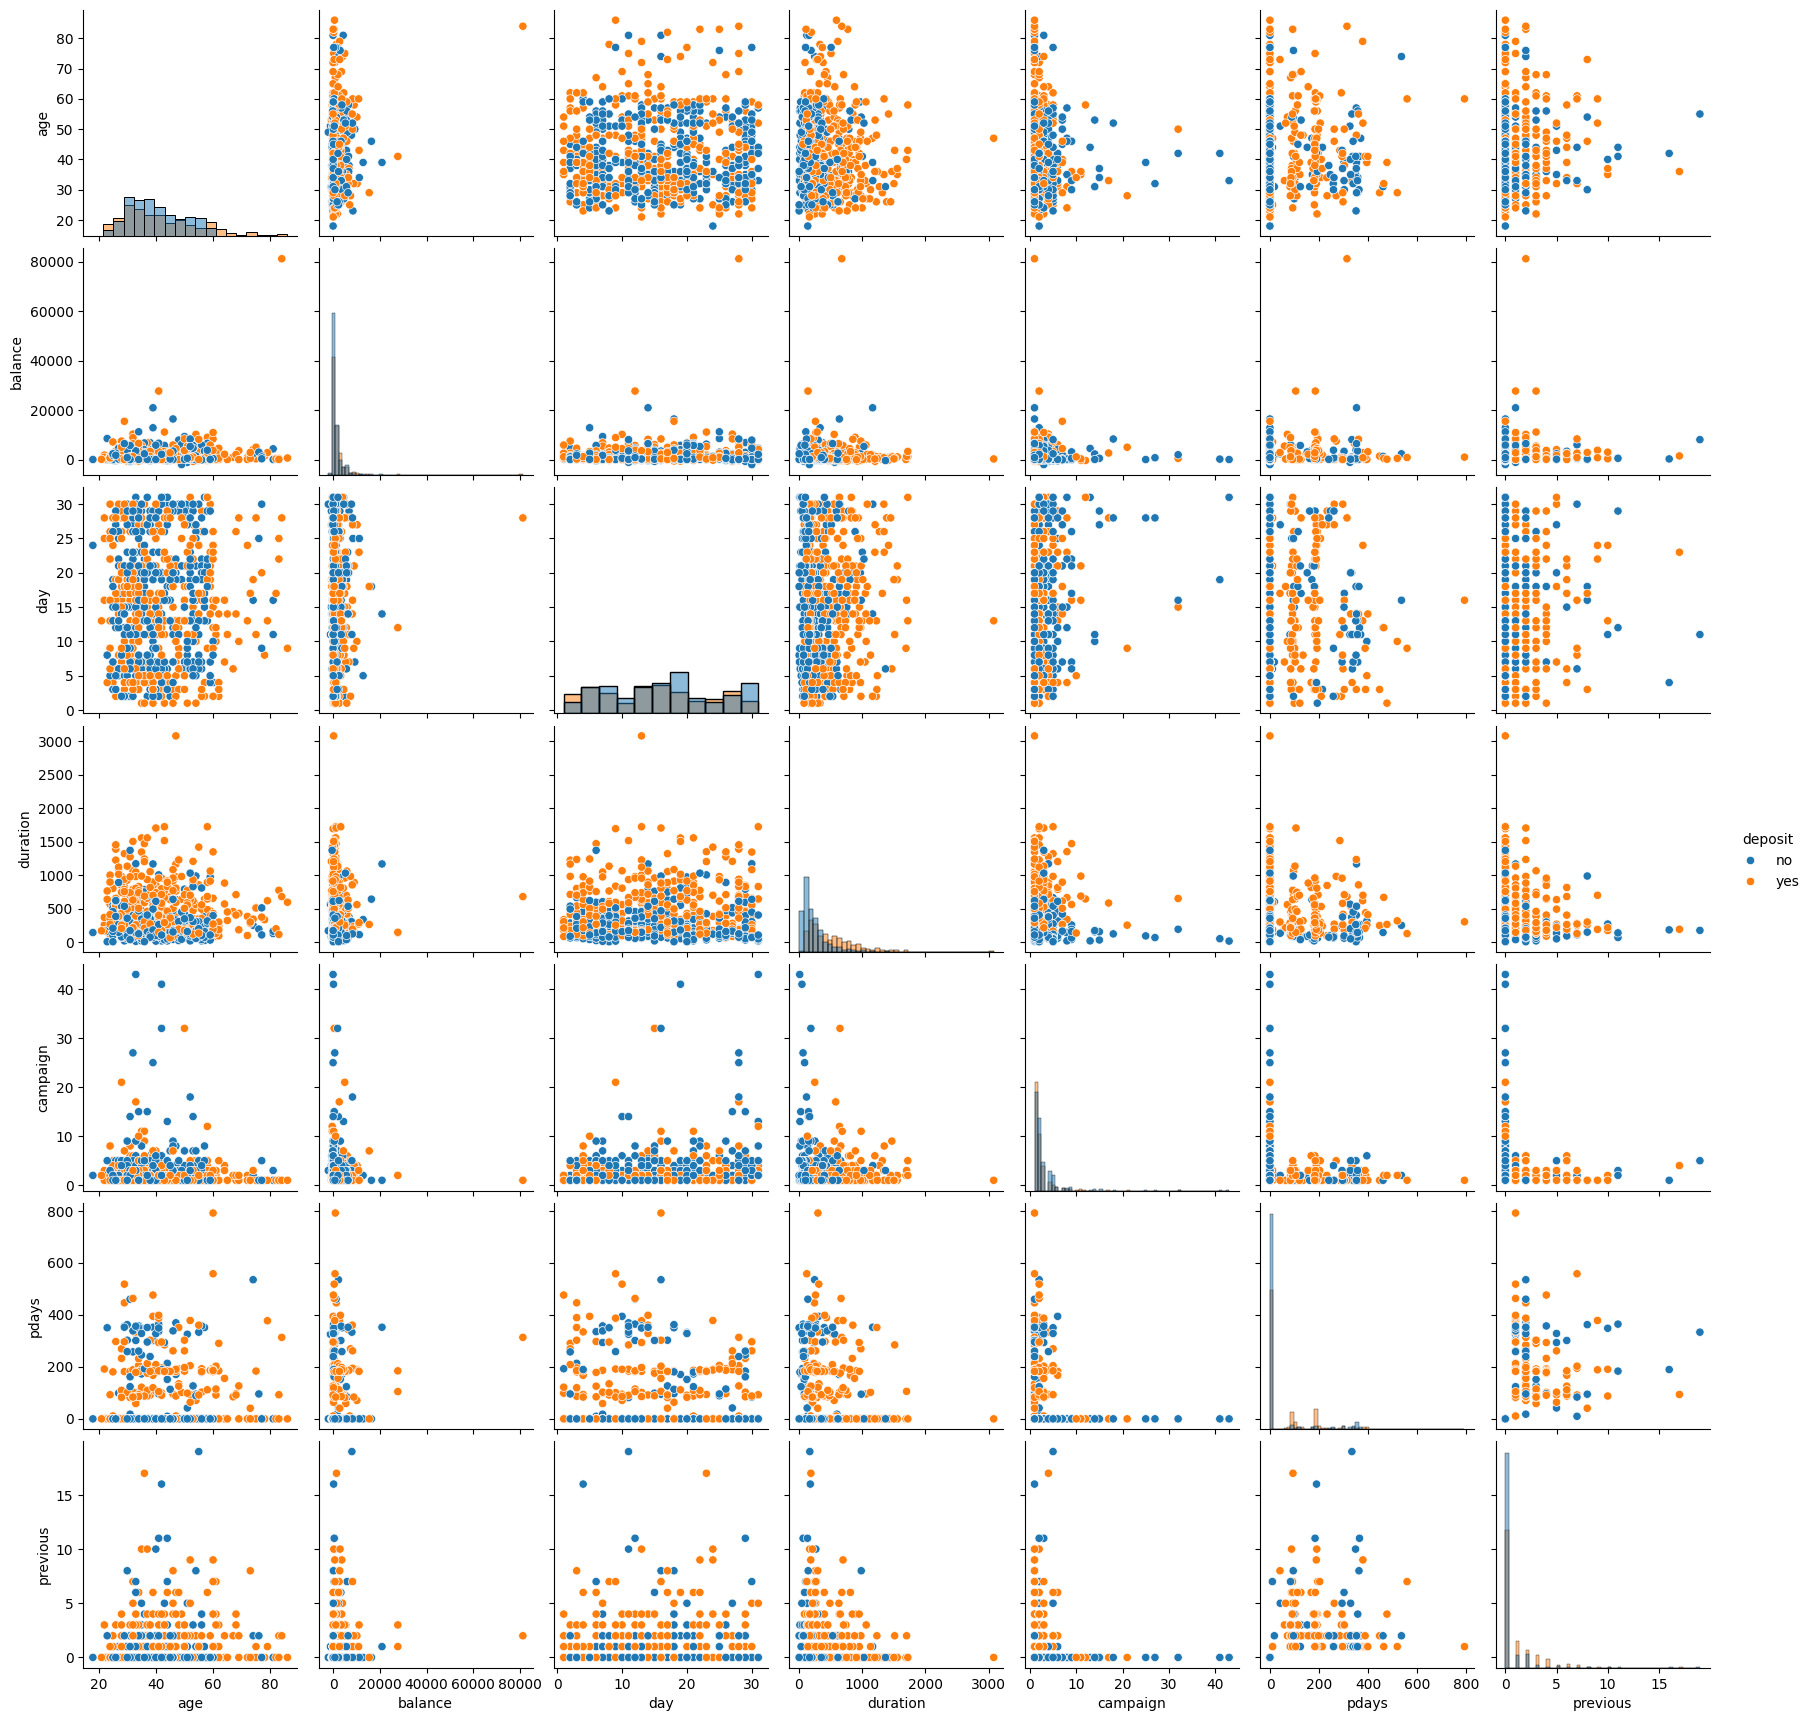

In [13]:
#pairplot
sample_df = df[num_cols + [target_col]].sample(n=min(800, len(df)), random_state=0)
sns.pairplot(sample_df, hue=target_col, diag_kind="hist")
plt.show()

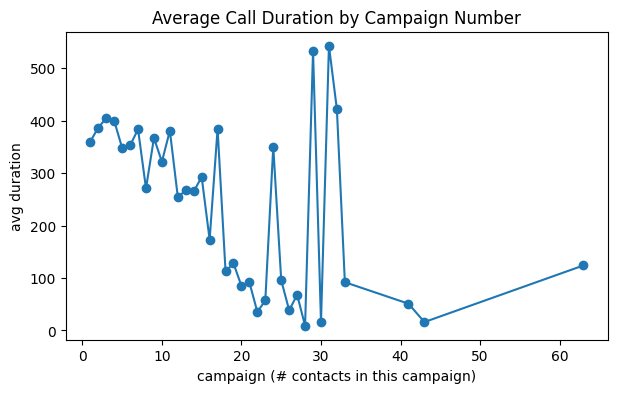

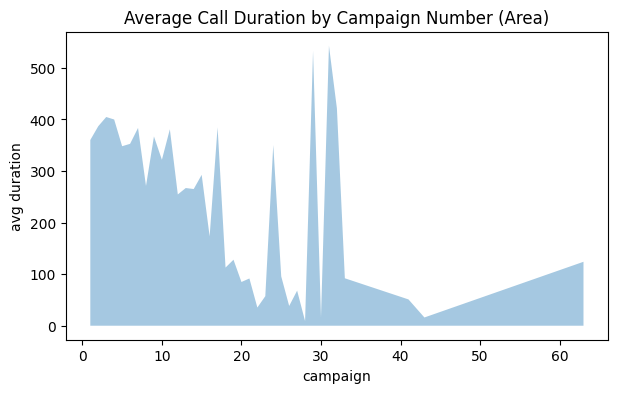

In [14]:
# Trend of average duration by campaign number (acts like an ordered axis)
if "campaign" in df.columns and "duration" in df.columns:
    trend = df.groupby("campaign")["duration"].mean().sort_index()

    plt.figure(figsize=(7,4))
    plt.plot(trend.index, trend.values, marker="o")
    plt.title("Average Call Duration by Campaign Number")
    plt.xlabel("campaign (# contacts in this campaign)")
    plt.ylabel("avg duration")
    plt.show()

    # Area version
    plt.figure(figsize=(7,4))
    plt.fill_between(trend.index, trend.values, alpha=0.4)
    plt.title("Average Call Duration by Campaign Number (Area)")
    plt.xlabel("campaign")
    plt.ylabel("avg duration")
    plt.show()

Bivariate conclusions (Bank Marketing dataset):

I examined correlations, scatterplots, and pairplots among numeric variables (age, balance, duration, campaign, pdays, previous). Many numeric pairs show low linear correlation, which suggests the dataset is not dominated by redundant numeric features. However, the scatterplots show outliers in variables such as balance and duration (extremely high values), which is expected in real marketing/finance data but may require preprocessing later (log transform, robust scaling, or winsorizing).

When comparing relationships using the conversion outcome (deposit/y), duration shows noticeable separation: customers who convert tend to have higher durations. This suggests duration is likely a strong predictive feature for marketing conversion propensity.

Overall, the data behave realistically and appear usable. Outliers exist but do not invalidate the dataset; they simply indicate that careful preprocessing will be important before building models.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

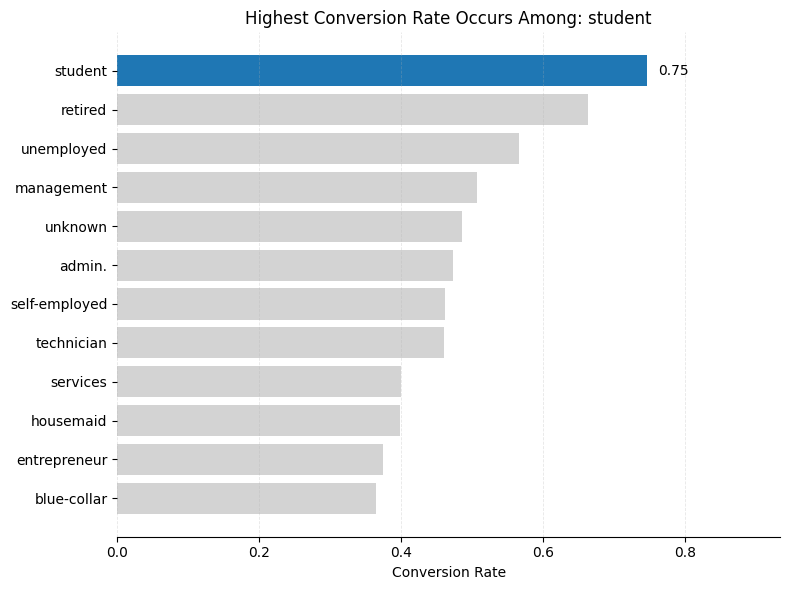

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset safely
df = pd.read_csv("bank.csv")
if df.shape[1] == 1:
    df = pd.read_csv("bank.csv", sep=";")

df.columns = df.columns.str.strip().str.lower()

# Identify target column
target_col = "deposit" if "deposit" in df.columns else "y"

# Calculate conversion rate by job
job_rate = (
    df[target_col].astype(str).str.lower().eq("yes")
    .groupby(df["job"])
    .mean()
    .sort_values()
)

# Highlight highest converting job
highlight_job = job_rate.idxmax()

plt.figure(figsize=(8,6))
ax = plt.gca()

# Strategic contrast: gray for most, strong color for highlight
colors = ["lightgray" if job != highlight_job else "#1f77b4" 
          for job in job_rate.index]

ax.barh(job_rate.index, job_rate.values, color=colors)

# Remove clutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.3)
ax.grid(axis="y", visible=False)

ax.set_title("Highest Conversion Rate Occurs Among: " + highlight_job)
ax.set_xlabel("Conversion Rate")
ax.set_ylabel("")

# Direct label instead of legend
ax.text(job_rate.max()*1.02,
        list(job_rate.index).index(highlight_job),
        f"{job_rate.max():.2f}",
        va="center")

ax.set_xlim(0, job_rate.max()*1.25)

plt.tight_layout()
plt.show()

This visualization applies the principles discussed in Chapter 3, particularly the strategic use of contrast and decluttering.

Instead of using multiple strong colors, only the most important category (the job with the highest conversion rate) is highlighted in blue, while the remaining categories are muted in gray. This strategic contrast directs the viewer’s attention immediately to the key insight.

Unnecessary chart elements were removed, including extra borders and heavy gridlines. Only subtle x-axis gridlines remain to support interpretation without overwhelming the data. Direct labeling was used instead of a legend to reduce cognitive load and improve clarity.

White space and alignment improve readability, and the horizontal bar layout ensures job labels are easy to scan. This design reflects Chapter 3’s emphasis on removing clutter so the data and the intended message stand out clearly.